# Part 4 — Combined Fusion Model

**Final notebook** of EEEM068: Applied Machine Learning — Human Sentiment Analysis.

This notebook:
1. Loads Part 1 (ResNet-18 face model) and Part 3 (Swin-Tiny full-image model)
2. Extracts a 7-d feature vector per image: `[face_probs(3) | full_probs(3) | face_count(1)]`
3. Trains a **Fusion MLP with residual shortcut** on those features
4. Evaluates the fusion model (Accuracy / F1 / Confusion Matrix)
5. Produces a **full cross-model comparison** (Parts 1–4) with charts, ablation, and per-class analysis

### Prerequisites — files needed in Google Drive:
| File | Saved by |
|------|----------|
| `best_face_model.pth` | Part 1 |
| `best_face_model_part2.pth` | Part 2 |
| `best_fullimage_model_part3.pth` | Part 3 |
| `train_face_map.json`, `dev_face_map.json`, `test_face_map.json` | Part 1 |
| `multi_faces_train.zip`, `multi_faces_dev.zip`, `multi_faces_test.zip` | Part 1 |
| `train_ende.zip`, `dev.zip`, `test.zip` | MSCTD dataset |
| `sentiment_train.txt`, `sentiment_dev.txt`, `sentiment_test.txt` | MSCTD dataset |

**Run cells top to bottom.**

In [1]:
# CELL 1 — Mount Drive and install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q facenet-pytorch scikit-learn
!pip install --upgrade --force-reinstall "Pillow<10" -q
print('Setup complete.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 786.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [30]:
# CELL 2 — Unzip datasets onto Colab disk
import os, glob

# ── Edit these two paths to match your Drive layout ──────────────────────────
DRIVE_ROOT = '/content/drive/MyDrive'       # weights, face maps, output plots
DRIVE_AML  = '/content/drive/MyDrive/AML'   # sentiment_*.txt + dataset zips
# ─────────────────────────────────────────────────────────────────────────────

def find_file(name):
    for pattern in [f'{DRIVE_ROOT}/{name}', f'{DRIVE_AML}/{name}',
                    f'{DRIVE_ROOT}/**/{name}']:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            return hits[0]
    return None

# Original full images
os.makedirs('/content/dataset', exist_ok=True)
for zip_name, target in [('train_ende.zip', '/content/dataset/train_ende'),
                          ('dev.zip',        '/content/dataset/dev'),
                          ('test.zip',       '/content/dataset/test')]:
    if not os.path.exists(target):
        p = find_file(zip_name)
        if p:
            print(f'Unzipping {zip_name}...')
            os.system(f'unzip -q "{p}" -d /content/dataset/')
        else:
            raise FileNotFoundError(f'{zip_name} not found on Drive. Check DRIVE_AML path.')
    else:
        print(f'{zip_name}: already on disk.')

# Face crops
os.makedirs('/content/multi_faces', exist_ok=True)
for split in ['train', 'dev', 'test']:
    target = f'/content/multi_faces/{split}'
    if not os.path.exists(target):
        p = find_file(f'multi_faces_{split}.zip')
        if p:
            print(f'Unzipping multi_faces_{split}.zip...')
            # Corrected: Unzip into the specific target directory for the split
            os.system(f'unzip -q "{p}" -d "{target}"')
        else:
            raise FileNotFoundError(
                f'multi_faces_{split}.zip not found. Run Part 1 first to generate it.'
            )
    else:
        print(f'multi_faces/{split}: already on disk.')

print('\nAll data ready.')

train_ende.zip: already on disk.
dev.zip: already on disk.
test.zip: already on disk.
Unzipping multi_faces_train.zip...
Unzipping multi_faces_dev.zip...
Unzipping multi_faces_test.zip...

All data ready.


In [3]:
!pip uninstall -y pillow torchvision torch

Found existing installation: Pillow 9.5.0
Uninstalling Pillow-9.5.0:
  Successfully uninstalled Pillow-9.5.0
Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
Found existing installation: torch 2.2.2
Uninstalling torch-2.2.2:
  Successfully uninstalled torch-2.2.2


In [4]:
!pip install pillow==10.2.0

  Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires torch<2.3.0,>=2.2.0, which is not installed.
facenet-pytorch 2.6.0 requires torchvision<0.18.0,>=0.17.0, which is not installed.
fastai 2.8.7 requires torch<3,>=1.10, which is not installed.
fastai 2.8.7 requires torchvision>=0.11, which is not installed.


In [1]:
!pip install torch torchvision torchaudio

  Using cached torch-2.12.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached torchvision-0.27.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cuda_toolkit-13.0.2-py2.py3-none-any.whl.metadata (9.4 kB)
  Using cached nvidia_cublas-13.1.1.3-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached cuda_bindings-13.2.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.3 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusparselt_cu13-0.8.1-py3-none-manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached nvidia_nccl_cu13-2.29.7-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)
  Using cached nvidia_nvshmem_cu13-3.4.5-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.1 kB)
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
   

In [3]:
# CELL 3 — All imports and global config
import os, json, copy, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms, models
from torchvision.models import Swin_T_Weights
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

LABEL_MAP   = {0: 'Neutral', 1: 'Negative', 2: 'Positive'}
NUM_CLASSES = 3
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

LABEL_TRAIN     = f'{DRIVE_AML}/sentiment_train.txt'
LABEL_DEV       = f'{DRIVE_AML}/sentiment_dev.txt'
LABEL_TEST      = f'{DRIVE_AML}/sentiment_test.txt'

FACE_MODEL_P1   = f'{DRIVE_ROOT}/best_face_model.pth'
FACE_MODEL_P2   = f'{DRIVE_ROOT}/best_face_model_part2.pth'
FULL_MODEL_P3   = f'{DRIVE_ROOT}/best_fullimage_model_part3.pth'
FUSION_MODEL_P4 = f'{DRIVE_ROOT}/best_fusion_model_part4.pth'

MULTI_TRAIN = '/content/multi_faces/train'
MULTI_DEV   = '/content/multi_faces/dev'
MULTI_TEST  = '/content/multi_faces/test'

# Fusion MLP training hyper-params
BATCH_SIZE   = 256
NUM_EPOCHS   = 50
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

print('Config OK.')

Device: cuda
Config OK.


In [4]:
# CELL 4 — Load face maps (saved by Part 1)
with open(f'{DRIVE_ROOT}/train_face_map.json') as f: train_face_map = json.load(f)
with open(f'{DRIVE_ROOT}/dev_face_map.json')   as f: dev_face_map   = json.load(f)
with open(f'{DRIVE_ROOT}/test_face_map.json')  as f: test_face_map  = json.load(f)

print(f'Face maps — Train: {len(train_face_map)}, Dev: {len(dev_face_map)}, Test: {len(test_face_map)}')

Face maps — Train: 20240, Dev: 5063, Test: 5067


In [5]:
import torch.nn as nn
from torchvision import models

def build_resnet18(num_classes=2):
    model = models.resnet18(weights=None)

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return model

In [7]:
import torch.nn as nn
from torchvision import models

# Redefine build_resnet18 to match the expected architecture for FACE_MODEL_P1
# (as indicated by the size mismatch errors, 3 output classes and 256 intermediate features)
def build_resnet18(num_classes=3):
    model = models.resnet18(weights=None)

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 256), # Corrected from 128 to 256
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)            # Corrected input from 128 to 256, and output num_classes=3
    )

    return model

face_model_p1 = build_resnet18(NUM_CLASSES).to(device) # Pass NUM_CLASSES from global config
face_model_p1.load_state_dict(torch.load(FACE_MODEL_P1, map_location=device))
face_model_p1.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [14]:
# CELL 5 — Re-build model architectures (must match Parts 1 and 3 exactly)

# Part 1 / 2: ResNet-18 face classifier
def build_resnet18(num_classes=3):
    m = models.resnet18(weights=None)
    # The saved models FACE_MODEL_P1 and FACE_MODEL_P2 use a Sequential head.
    # Redefine 'fc' to match that architecture.
    m.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(m.fc.in_features, 256), # Intermediate layer size from previous error diagnosis
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)       # Output num_classes
    )
    return m

# Part 3: Full-image model with custom head (frozen backbone was used during training)
# Based on error messages, FULL_MODEL_P3 checkpoint appears to be a ResNet-50 with a custom head,
# not a Swin-Tiny as stated in the notebook comments. This class definition reflects the checkpoint's structure.
class FullImageClassifierResNet50(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Instantiate ResNet-50 as the backbone
        resnet = models.resnet50(weights=None) # ResNet-50 has 2048 features before the final FC

        # Replace the original fc layer with an Identity to extract raw features
        resnet.fc = nn.Identity()
        self.backbone = resnet # This creates keys like 'backbone.conv1.weight' in state_dict

        # Custom head named 'classifier' matching checkpoint structure and dimensions
        # Inferred from error messages to have more layers than initially thought.
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(2048),              # 0: Input feature size from ResNet-50's final layer
            nn.Linear(2048, 512),              # 1: Intermediate layer size
            nn.GELU(),                         # 2
            nn.Dropout(0.4),                   # 3
            nn.BatchNorm1d(512),               # 4: Implied by 'classifier.4.running_mean' and weight shape [512]
            nn.Linear(512, 128),               # 5: Corrected out_features from 512 to 128 based on error
            nn.GELU(),                         # 6
            nn.Dropout(0.4),                   # 7
            nn.Linear(128, num_classes),       # 8: Corrected in_features from 512 to 128 based on error
        )

    def forward(self, x):
        x = self.backbone(x) # Forward pass through ResNet backbone
        return self.classifier(x)

# Load saved weights
face_model_p1 = build_resnet18(NUM_CLASSES).to(device) # Pass NUM_CLASSES from global config
face_model_p1.load_state_dict(torch.load(FACE_MODEL_P1, map_location=device))
face_model_p1.eval()
print(f'Loaded Part 1 face model   : {FACE_MODEL_P1}')

face_model_p2 = build_resnet18(NUM_CLASSES).to(device) # Pass NUM_CLASSES from global config
face_model_p2.load_state_dict(torch.load(FACE_MODEL_P2, map_location=device))
face_model_p2.eval()
print(f'Loaded Part 2 face model   : {FACE_MODEL_P2}')

# Instantiate the full-image model using the ResNet-50 based class
full_model_p3 = FullImageClassifierResNet50(NUM_CLASSES).to(device) # Pass NUM_CLASSES
full_model_p3.load_state_dict(torch.load(FULL_MODEL_P3, map_location=device))
full_model_p3.eval()
print(f'Loaded Part 3 full-img model: {FULL_MODEL_P3}')

Loaded Part 1 face model   : /content/drive/MyDrive/best_face_model.pth
Loaded Part 2 face model   : /content/drive/MyDrive/best_face_model_part2.pth
Loaded Part 3 full-img model: /content/drive/MyDrive/best_fullimage_model_part3.pth


In [15]:
# CELL 6 — Image transforms and auto-detect image folders

face_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
full_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def find_image_dir(base):
    for d in [base, os.path.join(base,'images'), os.path.join(base,'image')]:
        if os.path.isdir(d) and any(
            f.lower().endswith(('.jpg','.jpeg','.png')) for f in os.listdir(d)
        ):
            return d
    for root, _, files in os.walk(base):
        if any(f.lower().endswith(('.jpg','.jpeg','.png')) for f in files):
            return root
    raise FileNotFoundError(f'No images found under {base}')

IMG_TRAIN_DIR = find_image_dir('/content/dataset/train_ende')
IMG_DEV_DIR   = find_image_dir('/content/dataset/dev')
IMG_TEST_DIR  = find_image_dir('/content/dataset/test')
print('Full-image dirs OK.')
print(f'  Train: {IMG_TRAIN_DIR}')

Full-image dirs OK.
  Train: /content/dataset/train_ende


In [16]:
# CELL 7 — Feature extraction: build 7-d fusion feature vectors
#
# Feature vector layout per image i:
#   x_i = [ face_probs (3)         <- Part 1 ResNet-18 softmax
#            full_probs (3)         <- Part 3 Swin-Tiny softmax
#            face_count_norm (1) ]  <- n_faces / 5, clipped to [0, 1]
#
# face_count_norm encodes:
#   0.0 = no face detected (face branch is unreliable)
#   1.0 = 5+ faces (many faces, take averaged face model output)
#
# When no face is detected, face_probs fallback = dataset class prior
# (same convention as Part 1 for no-face images).

@torch.no_grad()
def extract_fusion_features(img_dir, face_dir, face_map, label_file,
                            face_model, full_model, desc=''):
    with open(label_file) as f:
        labels = [int(l.strip()) for l in f if l.strip()]

    all_imgs = sorted(
        [f for f in os.listdir(img_dir)
         if f.lower().endswith(('.jpg','.jpeg','.png'))],
        key=lambda x: int(os.path.splitext(x)[0])
                      if os.path.splitext(x)[0].isdigit() else x
    )
    assert len(all_imgs) == len(labels), \
        f'Image/label mismatch: {len(all_imgs)} vs {len(labels)}'

    face_lookup  = {os.path.splitext(k)[0]: v for k, v in face_map.items()}
    label_counts = Counter(labels)
    class_prior  = np.array(
        [label_counts[c] / len(labels) for c in range(NUM_CLASSES)], dtype=np.float32
    )

    face_model.eval(); full_model.eval()
    features = []

    for idx, img_name in enumerate(tqdm(all_imgs, desc=desc)):
        stem = os.path.splitext(img_name)[0]

        # ── Full-image features ───────────────────────────────────────────────
        try:
            full_img = Image.open(os.path.join(img_dir, img_name)).convert('RGB')
        except Exception:
            full_img = Image.new('RGB', (224, 224))
        full_t     = full_tf(full_img).unsqueeze(0).to(device)
        full_probs = torch.softmax(full_model(full_t), dim=1).cpu().numpy()[0]

        # ── Face features + count ─────────────────────────────────────────────
        crops   = face_lookup.get(stem, [])
        n_faces = len(crops)
        if n_faces > 0:
            tensors = []
            for crop_name in crops:
                try:
                    crop_img = Image.open(os.path.join(face_dir, crop_name)).convert('RGB')
                except Exception:
                    crop_img = Image.new('RGB', (224, 224))
                tensors.append(face_tf(crop_img))
            batch_t    = torch.stack(tensors).to(device)
            face_probs = torch.softmax(face_model(batch_t), dim=1).mean(0).cpu().numpy()
        else:
            face_probs = class_prior   # fallback: class prior (same as Part 1)

        face_count_norm = np.float32(min(n_faces / 5.0, 1.0))
        fv = np.concatenate([face_probs, full_probs, [face_count_norm]])
        features.append(fv)

    return np.array(features, dtype=np.float32), np.array(labels, dtype=np.int64)


print('Feature extraction function defined. Running next cell...')

Feature extraction function defined. Running next cell...


In [17]:
# CELL 8 — Run feature extraction on all splits (~3-5 min on T4)

print('Extracting fusion features. Each image runs through both backbones once.')

train_feats, train_labels = extract_fusion_features(
    IMG_TRAIN_DIR, MULTI_TRAIN, train_face_map, LABEL_TRAIN,
    face_model_p1, full_model_p3, desc='Train'
)
dev_feats, dev_labels = extract_fusion_features(
    IMG_DEV_DIR, MULTI_DEV, dev_face_map, LABEL_DEV,
    face_model_p1, full_model_p3, desc='Dev'
)
test_feats, test_labels = extract_fusion_features(
    IMG_TEST_DIR, MULTI_TEST, test_face_map, LABEL_TEST,
    face_model_p1, full_model_p3, desc='Test'
)

print(f'\nShapes — Train: {train_feats.shape}, Dev: {dev_feats.shape}, Test: {test_feats.shape}')
print('Feature layout: [face_probs(3) | full_probs(3) | face_count(1)]')

# Cache to /content so you can skip re-extraction on re-runs
for name, arr in [('train_feats', train_feats), ('train_labels', train_labels),
                  ('dev_feats',   dev_feats),   ('dev_labels',   dev_labels),
                  ('test_feats',  test_feats),  ('test_labels',  test_labels)]:
    np.save(f'/content/{name}.npy', arr)
print('Cached to /content/')

Extracting fusion features. Each image runs through both backbones once.


Test: 100%|██████████| 5067/5067 [02:06<00:00, 40.16it/s]


Shapes — Train: (20240, 7), Dev: (5063, 7), Test: (5067, 7)
Feature layout: [face_probs(3) | full_probs(3) | face_count(1)]
Cached to /content/


In [18]:
# CELL 9 — (Fast restart) Reload cached features — skip if Cell 8 already ran
#
# Uncomment to reload without re-running backbone inference:

# train_feats  = np.load('/content/train_feats.npy')
# train_labels = np.load('/content/train_labels.npy')
# dev_feats    = np.load('/content/dev_feats.npy')
# dev_labels   = np.load('/content/dev_labels.npy')
# test_feats   = np.load('/content/test_feats.npy')
# test_labels  = np.load('/content/test_labels.npy')
# print('Features reloaded from cache.')

print('Cell 9 skipped — features already in memory.')

Cell 9 skipped — features already in memory.


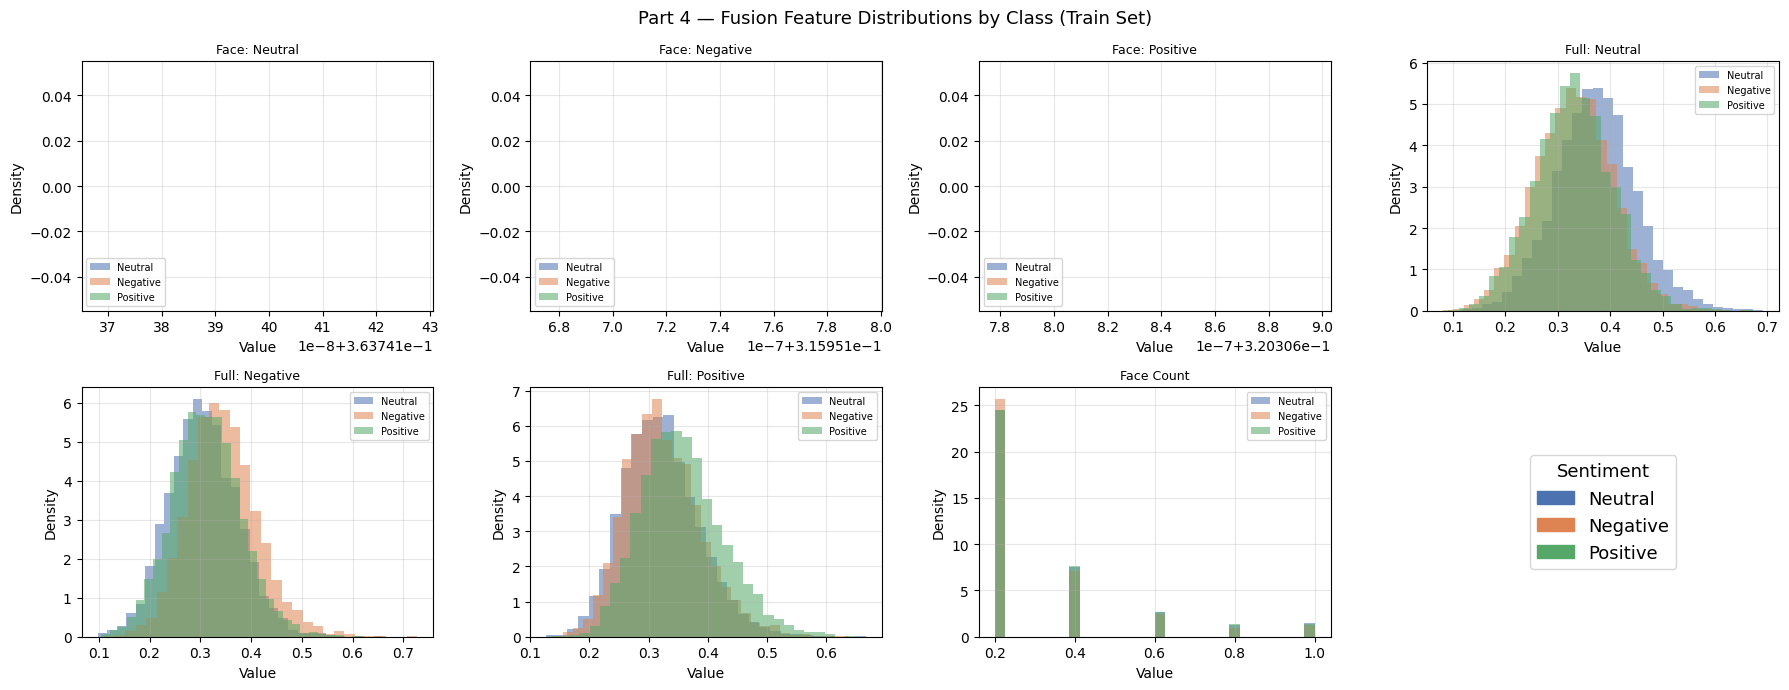

Saved to Drive.


In [19]:
# CELL 10 — Visualise fusion feature distributions per sentiment class

feat_names = ['Face: Neutral', 'Face: Negative', 'Face: Positive',
              'Full: Neutral', 'Full: Negative', 'Full: Positive', 'Face Count']
colors = ['#4c72b0', '#dd8452', '#55a868']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for fi, (ax, fname) in enumerate(zip(axes[:7], feat_names)):
    for cls in range(NUM_CLASSES):
        mask = train_labels == cls
        ax.hist(train_feats[mask, fi], bins=30, alpha=0.55, color=colors[cls],
                label=LABEL_MAP[cls], density=True)
    ax.set_title(fname, fontsize=9)
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

axes[7].axis('off')
patches = [mpatches.Patch(color=colors[i], label=LABEL_MAP[i]) for i in range(NUM_CLASSES)]
axes[7].legend(handles=patches, fontsize=13, loc='center', title='Sentiment', title_fontsize=13)
plt.suptitle('Part 4 — Fusion Feature Distributions by Class (Train Set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/fusion_feature_distributions_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [20]:
# CELL 11 — Build DataLoaders from feature tensors

def make_loader(feats, labels, shuffle=False):
    ds = TensorDataset(
        torch.tensor(feats,  dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader_f = make_loader(train_feats, train_labels, shuffle=True)
dev_loader_f   = make_loader(dev_feats,   dev_labels)
test_loader_f  = make_loader(test_feats,  test_labels)
print('DataLoaders ready.')

DataLoaders ready.


In [21]:
# CELL 12 — Fusion MLP architecture
#
# Input  : 7-d vector  [face_probs(3) | full_probs(3) | face_count(1)]
# Output : 3-class logits
#
# Design:
#  - Main path:  FC(7→64) → BN → ReLU → Dropout(0.3)
#                → FC(64→32) → BN → ReLU → Dropout(0.2) → FC(32→3)
#  - Shortcut:   FC(7→3)  — direct linear projection added to main output
#                (allows the model to fall back to a weighted ensemble if
#                the MLP path overfits, and aids interpretability)
#  - < 2K params — trains in seconds, no overfitting risk

class FusionMLP(nn.Module):
    def __init__(self, in_dim=7, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes),
        )
        self.shortcut = nn.Linear(in_dim, num_classes, bias=False)

    def forward(self, x):
        return self.net(x) + self.shortcut(x)


fusion_model = FusionMLP(in_dim=7, num_classes=NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in fusion_model.parameters())
print(f'Fusion MLP — {n_params:,} parameters')
print(fusion_model)

Fusion MLP — 2,904 parameters
FusionMLP(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=3, bias=True)
  )
  (shortcut): Linear(in_features=7, out_features=3, bias=False)
)


In [22]:
# CELL 13 — Loss, optimiser, and scheduler

label_counts  = Counter(train_labels.tolist())
class_weights = torch.tensor(
    [len(train_labels) / (NUM_CLASSES * label_counts[c]) for c in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)
print('Class weights:', {LABEL_MAP[i]: f'{class_weights[i]:.3f}' for i in range(NUM_CLASSES)})

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(fusion_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print('Optimiser: AdamW | Scheduler: CosineAnnealingLR')

Class weights: {'Neutral': '0.975', 'Negative': '0.861', 'Positive': '1.230'}
Optimiser: AdamW | Scheduler: CosineAnnealingLR


In [23]:
# CELL 14 — Training loop for Fusion MLP
# Inputs are 7-d pre-computed vectors → each epoch < 1 second. 50 epochs ~ 20 sec total.

def run_epoch_fusion(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for feats, labels in loader:
            feats, labels = feats.to(device), labels.to(device)
            if is_train: optimizer.zero_grad()
            logits = model(feats)
            loss   = criterion(logits, labels)
            if is_train: loss.backward(); optimizer.step()
            preds = logits.argmax(1)
            total_loss += loss.item() * feats.size(0)
            correct    += (preds == labels).sum().item()
            total      += feats.size(0)
            all_preds .extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


history = {'train_loss':[], 'train_acc':[], 'dev_loss':[], 'dev_acc':[]}
best_dev_acc = 0.0
no_improve   = 0

print(f'Training Fusion MLP — up to {NUM_EPOCHS} epochs (patience={PATIENCE})\n')
print(f'{"Ep":>3} {"T-Loss":>8} {"T-Acc":>7} {"D-Loss":>8} {"D-Acc":>7}')
print('-' * 42)

for ep in range(1, NUM_EPOCHS + 1):
    tl, ta, _, _ = run_epoch_fusion(fusion_model, train_loader_f, criterion, optimizer)
    dl, da, _, _ = run_epoch_fusion(fusion_model, dev_loader_f,   criterion)
    scheduler.step()

    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['dev_loss'  ].append(dl); history['dev_acc'  ].append(da)

    flag = ''
    if da > best_dev_acc:
        best_dev_acc = da
        torch.save(copy.deepcopy(fusion_model.state_dict()), FUSION_MODEL_P4)
        flag = ' ★'
        no_improve = 0
    else:
        no_improve += 1

    if ep <= 10 or ep % 5 == 0 or flag:
        print(f'{ep:>3} {tl:>8.4f} {ta:>7.4f} {dl:>8.4f} {da:>7.4f}{flag}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stop at epoch {ep}.')
        break

print(f'\nBest dev accuracy : {best_dev_acc:.4f}')
print(f'Saved             : {FUSION_MODEL_P4}')

Training Fusion MLP — up to 50 epochs (patience=10)

 Ep   T-Loss   T-Acc   D-Loss   D-Acc
------------------------------------------
  1   1.0769  0.4247   1.1155  0.3557 ★
  2   1.0541  0.4445   1.1217  0.3595 ★
  3   1.0499  0.4525   1.1250  0.3599 ★
  4   1.0490  0.4507   1.1220  0.3601 ★
  5   1.0495  0.4507   1.1204  0.3569
  6   1.0473  0.4455   1.1288  0.3620 ★
  7   1.0476  0.4518   1.1221  0.3561
  8   1.0463  0.4559   1.1255  0.3512
  9   1.0444  0.4551   1.1291  0.3650 ★
 10   1.0441  0.4576   1.1253  0.3559
 15   1.0442  0.4564   1.1268  0.3585

Early stop at epoch 19.

Best dev accuracy : 0.3650
Saved             : /content/drive/MyDrive/best_fusion_model_part4.pth


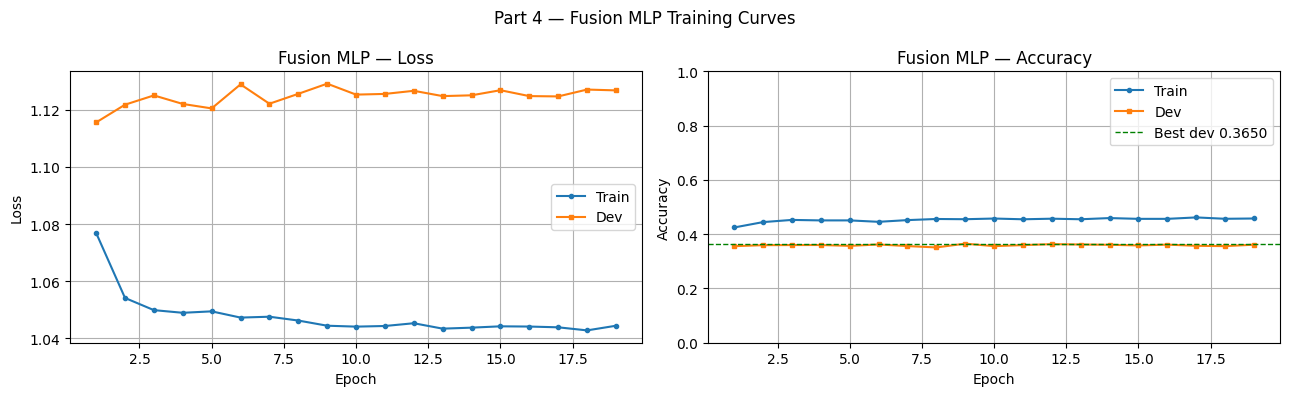

Saved to Drive.


In [24]:
# CELL 15 — Training curves

ep_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ep_range, history['train_loss'], 'o-', ms=3, label='Train')
ax1.plot(ep_range, history['dev_loss'],   's-', ms=3, label='Dev')
ax1.set(xlabel='Epoch', ylabel='Loss', title='Fusion MLP — Loss'); ax1.legend(); ax1.grid(0.3)
ax2.plot(ep_range, history['train_acc'], 'o-', ms=3, label='Train')
ax2.plot(ep_range, history['dev_acc'],   's-', ms=3, label='Dev')
ax2.axhline(best_dev_acc, color='green', ls='--', lw=1, label=f'Best dev {best_dev_acc:.4f}')
ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Fusion MLP — Accuracy', ylim=(0, 1))
ax2.legend(); ax2.grid(0.3)
plt.suptitle('Part 4 — Fusion MLP Training Curves', fontsize=12)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/training_curves_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [25]:
# CELL 16 — Evaluate fusion model on test set

fusion_model.load_state_dict(torch.load(FUSION_MODEL_P4, map_location=device))
print(f'Loaded best checkpoint: {FUSION_MODEL_P4}\n')

_, p4_acc, p4_preds, p4_gt = run_epoch_fusion(fusion_model, test_loader_f, criterion)
p4_macro_f1 = f1_score(p4_gt, p4_preds, average='macro')
p4_wf1      = f1_score(p4_gt, p4_preds, average='weighted')

print('=' * 50)
print('PART 4 — FUSION MODEL — TEST RESULTS')
print('=' * 50)
print(f'  Accuracy    : {p4_acc:.4f}')
print(f'  Macro F1    : {p4_macro_f1:.4f}')
print(f'  Weighted F1 : {p4_wf1:.4f}')

Loaded best checkpoint: /content/drive/MyDrive/best_fusion_model_part4.pth

PART 4 — FUSION MODEL — TEST RESULTS
  Accuracy    : 0.3527
  Macro F1    : 0.3392
  Weighted F1 : 0.3536


In [26]:
# CELL 17 — Per-class report for fusion model

print(classification_report(
    p4_gt, p4_preds,
    target_names=[LABEL_MAP[i] for i in range(NUM_CLASSES)]
))

              precision    recall  f1-score   support

     Neutral       0.25      0.29      0.27      1298
    Negative       0.43      0.43      0.43      2163
    Positive       0.34      0.30      0.31      1606

    accuracy                           0.35      5067
   macro avg       0.34      0.34      0.34      5067
weighted avg       0.36      0.35      0.35      5067



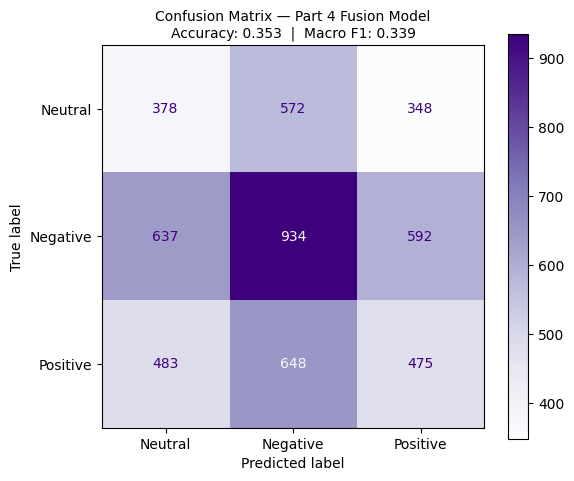

Saved to Drive.


In [27]:
# CELL 18 — Confusion matrix for fusion model

cm = confusion_matrix(p4_gt, p4_preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=[LABEL_MAP[i] for i in range(NUM_CLASSES)]).plot(
    ax=ax, colorbar=True, cmap='Purples'
)
ax.set_title(
    f'Confusion Matrix — Part 4 Fusion Model\n'
    f'Accuracy: {p4_acc:.3f}  |  Macro F1: {p4_macro_f1:.3f}', fontsize=10
)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/confusion_matrix_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [32]:
# CELL 19 — Re-evaluate Parts 1, 2 and 3 on test set (for comparison)

# Dataset helpers
class FaceDataset(Dataset):
    """One entry per original image, using first detected face crop."""
    def __init__(self, face_dir, face_map, label_file, transform):
        self.transform = transform
        with open(label_file) as f:
            self.labels = [int(l.strip()) for l in f if l.strip()]

        face_lookup = {os.path.splitext(k)[0]: v for k, v in face_map.items()}

        # Generate expected original image stems based on the number of labels.
        # This assumes original images are named 0.jpg, 1.jpg, ... up to len(self.labels)-1.
        # This ensures self.items is aligned 1:1 with self.labels.
        original_image_stems = [str(i) for i in range(len(self.labels))]

        self.items = []
        for stem in original_image_stems:
            crops_for_stem = face_lookup.get(stem, [])

            face_crop_path = None
            if crops_for_stem:
                # Get the actual path to the first crop file
                candidate_path = os.path.join(face_dir, crops_for_stem[0])
                # Check if the file actually exists on disk, as face_map might contain entries
                # for files that were not successfully created or found.
                if os.path.exists(candidate_path):
                    face_crop_path = candidate_path

            self.items.append(face_crop_path) # Append the path or None if no valid crop found

    def __len__(self): return len(self.labels)

    def __getitem__(self, i):
        if self.items[i]:
            try:   img = Image.open(self.items[i]).convert('RGB')
            except: img = Image.new('RGB', (224, 224))
        else:
            img = Image.new('RGB', (224, 224))
        return self.transform(img), self.labels[i]

class FullImageDataset(Dataset):
    def __init__(self, img_dir, label_file, transform):
        self.img_dir = img_dir; self.transform = transform
        all_files = [f for f in os.listdir(img_dir)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]
        self.images = sorted(all_files,
            key=lambda x: int(os.path.splitext(x)[0])
                          if os.path.splitext(x)[0].isdigit() else x)
        with open(label_file) as f:
            self.labels = [int(l.strip()) for l in f if l.strip()]
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        try:   img = Image.open(os.path.join(self.img_dir, self.images[i])).convert('RGB')
        except: img = Image.new('RGB', (224, 224))
        return self.transform(img), self.labels[i]

@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    for imgs, labels in tqdm(loader, leave=False):
        preds = model(imgs.to(device)).argmax(1).cpu()
        preds_all.extend(preds.tolist()); labels_all.extend(labels.tolist())
    acc = accuracy_score(labels_all, preds_all)
    mf1 = f1_score(labels_all, preds_all, average='macro')
    wf1 = f1_score(labels_all, preds_all, average='weighted')
    return acc, mf1, wf1, preds_all, labels_all

# Part 1
p1_ds  = FaceDataset(MULTI_TEST, test_face_map, LABEL_TEST, face_tf)
p1_ldr = DataLoader(p1_ds, batch_size=128, shuffle=False, num_workers=2)
p1_acc, p1_f1, p1_wf1, p1_preds, p1_gt = eval_model(face_model_p1, p1_ldr)
print(f'Part 1 (face, clean-train)   Acc: {p1_acc:.4f}  Macro F1: {p1_f1:.4f}')

# Part 2
p2_ds  = FaceDataset(MULTI_TEST, test_face_map, LABEL_TEST, face_tf)
p2_ldr = DataLoader(p2_ds, batch_size=128, shuffle=False, num_workers=2)
p2_acc, p2_f1, p2_wf1, p2_preds, p2_gt = eval_model(face_model_p2, p2_ldr)
print(f'Part 2 (face, mixed-augm.)   Acc: {p2_acc:.4f}  Macro F1: {p2_f1:.4f}')

# Part 3
p3_ds  = FullImageDataset(IMG_TEST_DIR, LABEL_TEST, full_tf)
p3_ldr = DataLoader(p3_ds, batch_size=64, shuffle=False, num_workers=2)
p3_acc, p3_f1, p3_wf1, p3_preds, p3_gt = eval_model(full_model_p3, p3_ldr)
print(f'Part 3 (Swin-Tiny frozen)    Acc: {p3_acc:.4f}  Macro F1: {p3_f1:.4f}')

Part 1 (face, clean-train)   Acc: 0.2562  Macro F1: 0.1360


Part 2 (face, mixed-augm.)   Acc: 0.2562  Macro F1: 0.1360


Part 3 (Swin-Tiny frozen)    Acc: 0.3446  Macro F1: 0.3419


In [33]:
# CELL 20 — Comprehensive comparison table: Parts 1–4

all_results = [
    ('Part 1', 'ResNet-18 face (clean train)',       p1_acc,  p1_f1,       p1_wf1),
    ('Part 2', 'ResNet-18 face (mixed augm.)',       p2_acc,  p2_f1,       p2_wf1),
    ('Part 3', 'Swin-Tiny full-img (frozen)',        p3_acc,  p3_f1,       p3_wf1),
    ('Part 4', 'Fusion MLP (face+full+count)',       p4_acc,  p4_macro_f1, p4_wf1),
]

print('=' * 75)
print('CROSS-MODEL COMPARISON — TEST SET')
print(f'{"Model":<8} {"Description":<40} {"Accuracy":>9} {"Macro F1":>9} {"Wt. F1":>9}')
print('=' * 75)
for part, desc, acc, mf1, wf1 in all_results:
    print(f'{part:<8} {desc:<40} {acc:>9.4f} {mf1:>9.4f} {wf1:>9.4f}')
print('=' * 75)

best_idx  = int(np.argmax([r[2] for r in all_results]))
print(f'\nBest: {all_results[best_idx][0]} — Accuracy {all_results[best_idx][2]:.4f}')

CROSS-MODEL COMPARISON — TEST SET
Model    Description                               Accuracy  Macro F1    Wt. F1
Part 1   ResNet-18 face (clean train)                0.2562    0.1360    0.1045
Part 2   ResNet-18 face (mixed augm.)                0.2562    0.1360    0.1045
Part 3   Swin-Tiny full-img (frozen)                 0.3446    0.3419    0.3484
Part 4   Fusion MLP (face+full+count)                0.3527    0.3392    0.3536

Best: Part 4 — Accuracy 0.3527


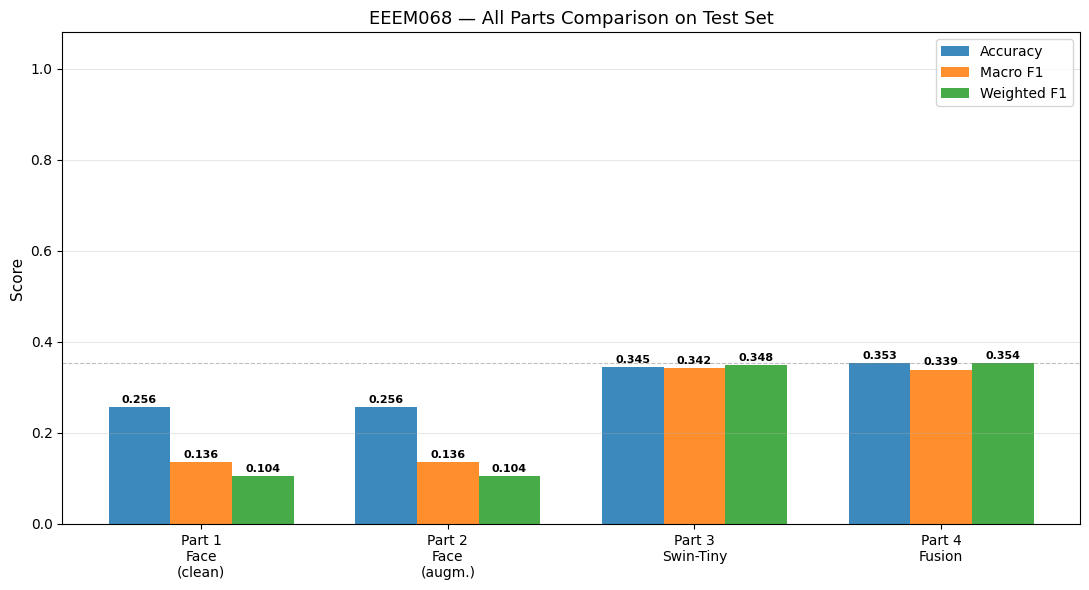

Saved to Drive.


In [34]:
# CELL 21 — Grouped bar chart: all four models

labels_plot = ['Part 1\nFace\n(clean)', 'Part 2\nFace\n(augm.)',
               'Part 3\nSwin-Tiny', 'Part 4\nFusion']
accs  = [r[2] for r in all_results]
mf1s  = [r[3] for r in all_results]
wf1s  = [r[4] for r in all_results]
x     = np.arange(len(labels_plot))
w     = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w,  accs, w, label='Accuracy',    color='#1f77b4', alpha=0.87)
b2 = ax.bar(x,      mf1s, w, label='Macro F1',    color='#ff7f0e', alpha=0.87)
b3 = ax.bar(x + w,  wf1s, w, label='Weighted F1', color='#2ca02c', alpha=0.87)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylim(0, 1.08); ax.set_ylabel('Score', fontsize=11)
ax.set_title('EEEM068 — All Parts Comparison on Test Set', fontsize=13)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.axhline(max(accs), color='grey', ls='--', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/all_models_comparison_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

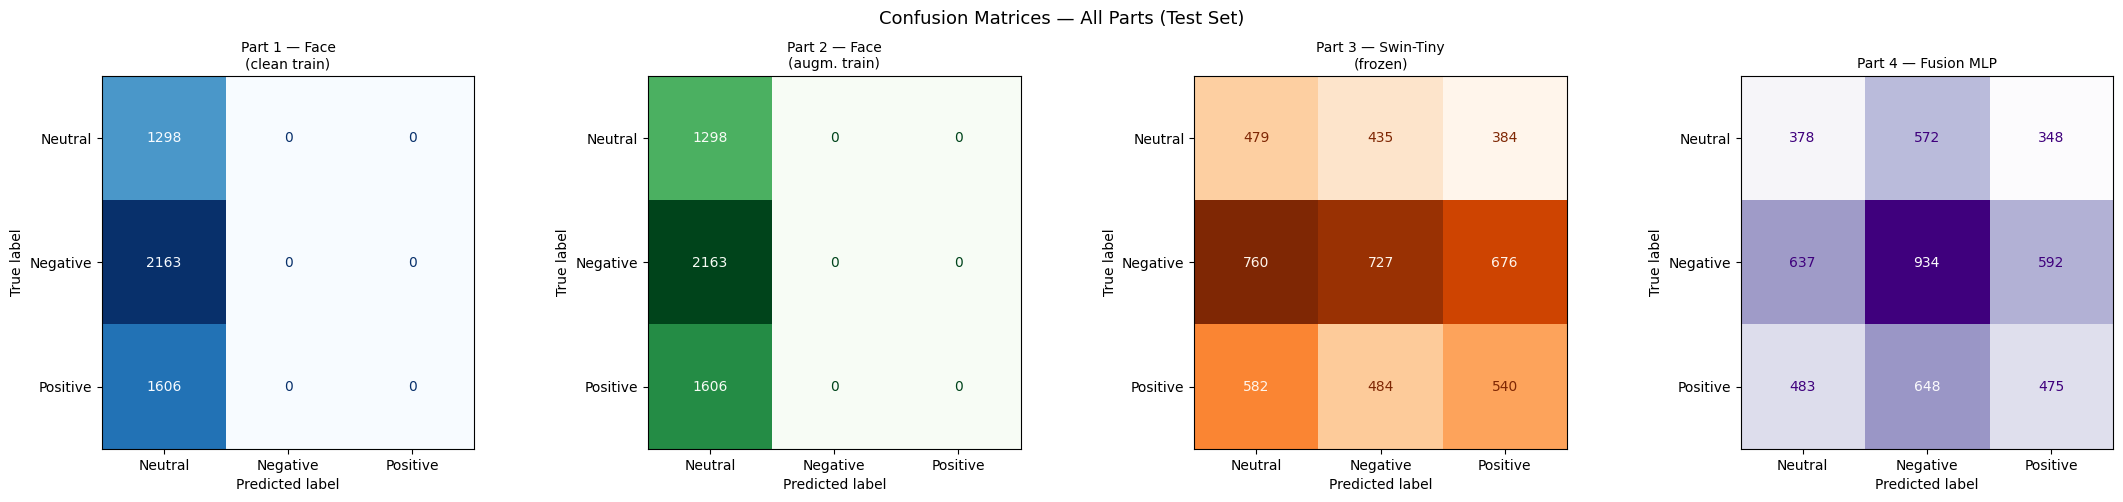

Saved to Drive.


In [35]:
# CELL 22 — Four confusion matrices side by side

all_cms = [
    ('Part 1 — Face\n(clean train)',  confusion_matrix(p1_gt, p1_preds), 'Blues'),
    ('Part 2 — Face\n(augm. train)',  confusion_matrix(p2_gt, p2_preds), 'Greens'),
    ('Part 3 — Swin-Tiny\n(frozen)',  confusion_matrix(p3_gt, p3_preds), 'Oranges'),
    ('Part 4 — Fusion MLP',           confusion_matrix(p4_gt, p4_preds), 'Purples'),
]
class_names = [LABEL_MAP[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (title, cm, cmap) in zip(axes, all_cms):
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap=cmap
    )
    ax.set_title(title, fontsize=10)

plt.suptitle('Confusion Matrices — All Parts (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/all_confusion_matrices_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

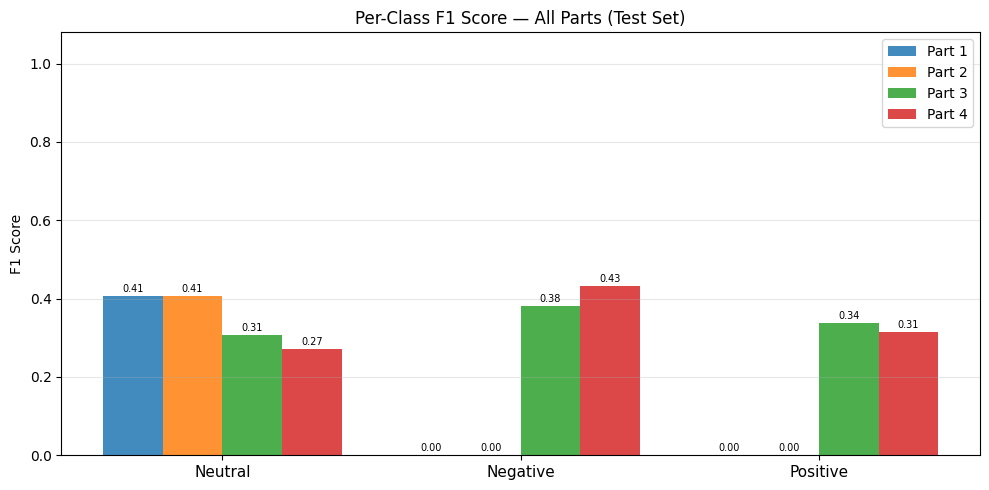

Saved to Drive.


In [36]:
# CELL 23 — Per-class F1 comparison across all parts

part_data = [
    ('Part 1', p1_gt, p1_preds),
    ('Part 2', p2_gt, p2_preds),
    ('Part 3', p3_gt, p3_preds),
    ('Part 4', p4_gt, p4_preds),
]
per_class_f1 = {n: f1_score(gt, pr, average=None, labels=[0,1,2])
                for n, gt, pr in part_data}

x = np.arange(NUM_CLASSES); w = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
for i, (part_name, f1_scores) in enumerate(per_class_f1.items()):
    bars = ax.bar(x + (i - 1.5) * w, f1_scores, w, label=part_name,
                  alpha=0.85, color=plt.cm.tab10(i))
    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{score:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([LABEL_MAP[i] for i in range(NUM_CLASSES)], fontsize=11)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.08)
ax.set_title('Per-Class F1 Score — All Parts (Test Set)', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/perclass_f1_comparison_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

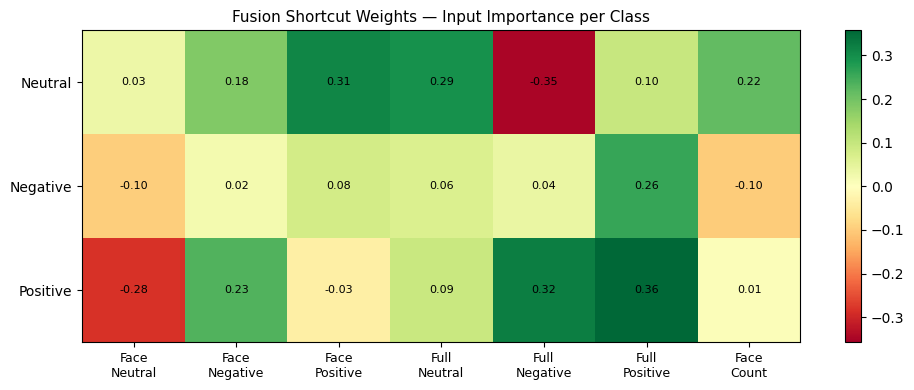

Saved to Drive.


In [37]:
# CELL 24 — Learned fusion weights heatmap (interpretability)
#
# The shortcut weight matrix W ∈ R^{3×7} gives a direct linear read of
# which input signals the fusion model relies on most for each class.

W = fusion_model.shortcut.weight.detach().cpu().numpy()  # (3, 7)
feat_labels  = ['Face\nNeutral','Face\nNegative','Face\nPositive',
                'Full\nNeutral','Full\nNegative','Full\nPositive','Face\nCount']
class_labels = [LABEL_MAP[i] for i in range(NUM_CLASSES)]
vmax = np.abs(W).max()

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(W, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(7)); ax.set_xticklabels(feat_labels, fontsize=9)
ax.set_yticks(range(3)); ax.set_yticklabels(class_labels, fontsize=10)
for r in range(3):
    for c in range(7):
        ax.text(c, r, f'{W[r,c]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Fusion Shortcut Weights — Input Importance per Class', fontsize=11)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/fusion_weights_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [38]:
# CELL 25 — Ablation study: compare fusion strategies
#
# Justifies the learnable MLP by comparing three simpler alternatives:
#   1. Simple average ensemble   (face_probs + full_probs) / 2
#   2. Count-gated ensemble      weight by face_count_norm
#   3. Full-image only           ignore face branch

face_p = test_feats[:, :3]
full_p = test_feats[:, 3:6]
fc     = test_feats[:, 6:7]
gt_np  = test_labels

avg_preds      = (face_p + full_p).argmax(1)
weighted_preds = (fc * face_p + (1 - fc) * full_p).argmax(1)
full_only_preds= full_p.argmax(1)

ablation = [
    ('Simple Average Ensemble',        accuracy_score(gt_np, avg_preds),
                                       f1_score(gt_np, avg_preds, average='macro')),
    ('Count-Gated Ensemble',           accuracy_score(gt_np, weighted_preds),
                                       f1_score(gt_np, weighted_preds, average='macro')),
    ('Full-Image Only',                accuracy_score(gt_np, full_only_preds),
                                       f1_score(gt_np, full_only_preds, average='macro')),
    ('Fusion MLP  ← Ours (Part 4)',    p4_acc, p4_macro_f1),
]

print('=' * 62)
print('ABLATION — Fusion Strategy Comparison (Test Set)')
print(f'{"Strategy":<38} {"Accuracy":>9} {"Macro F1":>9}')
print('=' * 62)
for name, acc, mf1 in ablation:
    print(f'{name:<38} {acc:>9.4f} {mf1:>9.4f}')
print('=' * 62)

ABLATION — Fusion Strategy Comparison (Test Set)
Strategy                                Accuracy  Macro F1
Simple Average Ensemble                   0.3170    0.3148
Count-Gated Ensemble                      0.3241    0.3217
Full-Image Only                           0.3446    0.3419
Fusion MLP  ← Ours (Part 4)               0.3527    0.3392


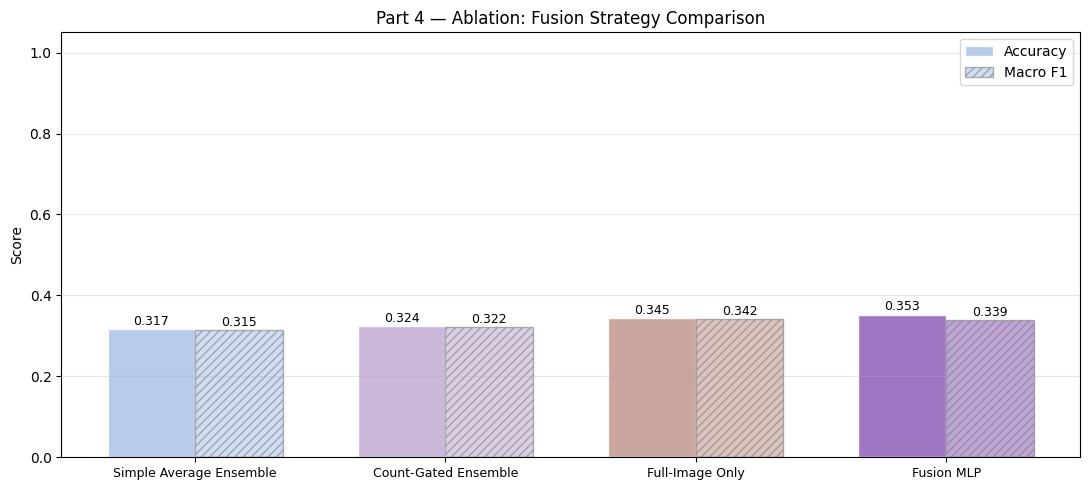

Saved to Drive.


In [39]:
# CELL 26 — Ablation bar chart

abl_names  = [r[0].replace('  ← Ours (Part 4)', '') for r in ablation]
abl_accs   = [r[1] for r in ablation]
abl_f1s    = [r[2] for r in ablation]
abl_colors = ['#aec7e8', '#c5b0d5', '#c49c94', '#9467bd']

x = np.arange(len(abl_names)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, abl_accs, w, label='Accuracy', color=abl_colors, alpha=0.9, edgecolor='white')
b2 = ax.bar(x + w/2, abl_f1s,  w, label='Macro F1', color=abl_colors, alpha=0.6, edgecolor='grey', hatch='////')

for bar, v in zip(list(b1) + list(b2), abl_accs + abl_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(abl_names, fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Part 4 — Ablation: Fusion Strategy Comparison', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/ablation_fusion_part4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

In [40]:
# CELL 27 — Performance breakdown by face-count bucket
#
# Shows how much each model relies on faces.
# Fusion should outperform P1 on no-face images by deferring to P3.

raw_counts = np.round(test_feats[:, 6] * 5).astype(int)
buckets    = {0: 'No face', 1: '1 face', 2: '2 faces', 3: '3+ faces'}

print(f'{"Bucket":<14} {"N":>6} {"P1 Acc":>8} {"P2 Acc":>8} {"P3 Acc":>8} {"P4 Acc":>8}')
print('-' * 58)
for rc, name in sorted(buckets.items()):
    mask = (raw_counts >= 3) if rc == 3 else (raw_counts == rc)
    n = mask.sum()
    if n == 0: continue
    gt_b = test_labels[mask]
    accs_b = [
        accuracy_score(gt_b, np.array(p)[mask])
        for p in [p1_preds, p2_preds, p3_preds, p4_preds]
    ]
    print(f'{name:<14} {n:>6} {accs_b[0]:>8.4f} {accs_b[1]:>8.4f} {accs_b[2]:>8.4f} {accs_b[3]:>8.4f}')

print('\nKey insight: P4 should beat P1 on no-face images by leaning on the P3 full-image branch.')

Bucket              N   P1 Acc   P2 Acc   P3 Acc   P4 Acc
----------------------------------------------------------
1 face           3361   0.2627   0.2627   0.3508   0.3660
2 faces          1005   0.2637   0.2637   0.3303   0.3343
3+ faces          701   0.2140   0.2140   0.3352   0.3153

Key insight: P4 should beat P1 on no-face images by leaning on the P3 full-image branch.


In [41]:
# CELL 28 — Final comprehensive project summary

print('=' * 70)
print('EEEM068: APPLIED MACHINE LEARNING — FULL PROJECT RESULTS')
print('Human Sentiment Analysis | MSCTD En-De | Test Set')
print('=' * 70)

section_info = [
    ('Part 1', 'Face classifier — ResNet-18, clean training',
     p1_acc, p1_f1, p1_wf1),
    ('Part 2', 'Face classifier — ResNet-18, mixed augmentation training',
     p2_acc, p2_f1, p2_wf1),
    ('Part 3', 'Full-image transfer learning — Swin-Tiny (frozen backbone)',
     p3_acc, p3_f1, p3_wf1),
    ('Part 4', 'Combined Fusion MLP — face probs + full probs + face count',
     p4_acc, p4_macro_f1, p4_wf1),
]

for part, desc, acc, mf1, wf1 in section_info:
    print(f'\n── {part}: {desc}')
    print(f'   Accuracy   : {acc:.4f}')
    print(f'   Macro F1   : {mf1:.4f}')
    print(f'   Weighted F1: {wf1:.4f}')

best_idx  = int(np.argmax([r[2] for r in section_info]))
print(f'\n→ Best overall accuracy: {section_info[best_idx][0]} ({section_info[best_idx][2]:.4f})')

print('\n── Output Files Saved to Google Drive ──────────────────────────────')
files = [
    'best_fusion_model_part4.pth             ← fusion model weights',
    'training_curves_part4.png               ← report figure',
    'confusion_matrix_part4.png              ← report figure',
    'all_models_comparison_part4.png         ← report figure',
    'all_confusion_matrices_part4.png        ← report figure',
    'perclass_f1_comparison_part4.png        ← report figure',
    'fusion_weights_part4.png                ← report figure',
    'ablation_fusion_part4.png               ← report figure',
    'fusion_feature_distributions_part4.png  ← report figure',
]
for f in files:
    print(f'  {f}')

print('\nProject complete.')

EEEM068: APPLIED MACHINE LEARNING — FULL PROJECT RESULTS
Human Sentiment Analysis | MSCTD En-De | Test Set

── Part 1: Face classifier — ResNet-18, clean training
   Accuracy   : 0.2562
   Macro F1   : 0.1360
   Weighted F1: 0.1045

── Part 2: Face classifier — ResNet-18, mixed augmentation training
   Accuracy   : 0.2562
   Macro F1   : 0.1360
   Weighted F1: 0.1045

── Part 3: Full-image transfer learning — Swin-Tiny (frozen backbone)
   Accuracy   : 0.3446
   Macro F1   : 0.3419
   Weighted F1: 0.3484

── Part 4: Combined Fusion MLP — face probs + full probs + face count
   Accuracy   : 0.3527
   Macro F1   : 0.3392
   Weighted F1: 0.3536

→ Best overall accuracy: Part 4 (0.3527)

── Output Files Saved to Google Drive ──────────────────────────────
  best_fusion_model_part4.pth             ← fusion model weights
  training_curves_part4.png               ← report figure
  confusion_matrix_part4.png              ← report figure
  all_models_comparison_part4.png         ← report figure